In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
import xgboost as xgb
import matplotlib.pyplot as plt

import openbb as obb
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import norm, skewnorm, t

In [2]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
data = yf.download(tickers, start='2020-01-01', end='2025-01-01')["Close"]
returns = data.pct_change().dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed

4 Failed downloads:
['AAPL', 'GOOGL', 'MSFT', 'AMZN']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


In [3]:
returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,


<Axes: xlabel='Ticker', ylabel='Ticker'>

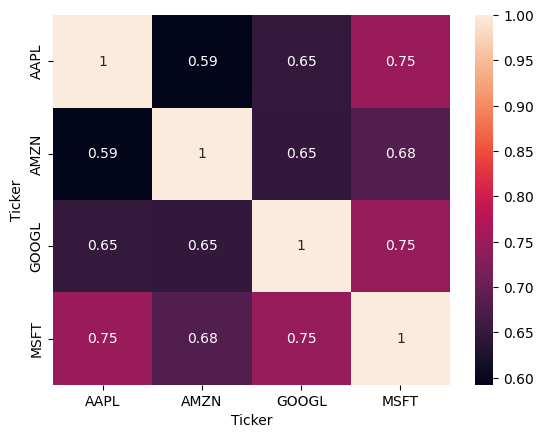

In [6]:
sns.heatmap(returns.corr(), annot=True)

<Axes: xlabel='AAPL', ylabel='Count'>

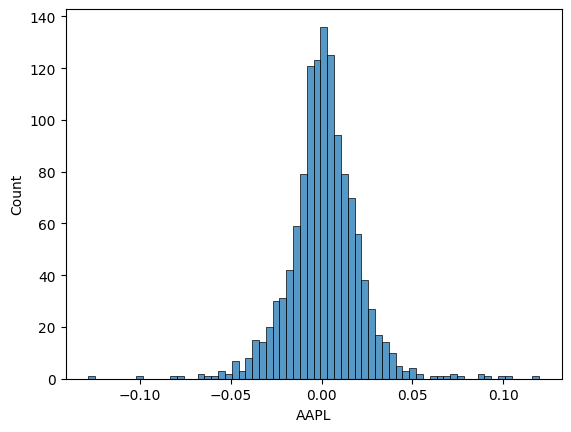

In [8]:
sns.histplot(returns["AAPL"])


In [10]:
from scipy import stats

In [11]:
p_value = stats.shapiro(returns["AAPL"])

In [12]:
p_value[1]

np.float64(9.818910358642451e-22)

In [13]:
skewnorm.fit(returns["AAPL"])

(np.float64(0.8337195282859107),
 np.float64(-0.010594171524905476),
 np.float64(0.023164409425648933))

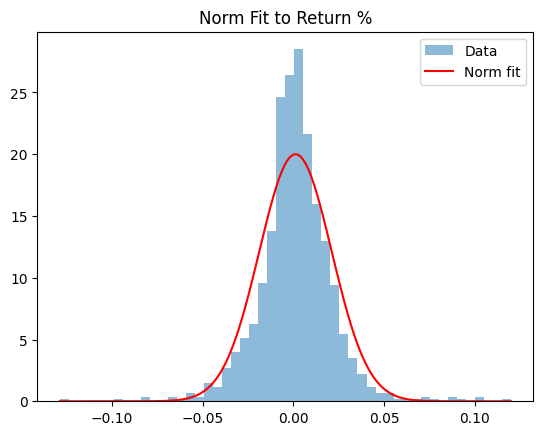

In [14]:
filtered = returns["AAPL"]
params_norm = norm.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()

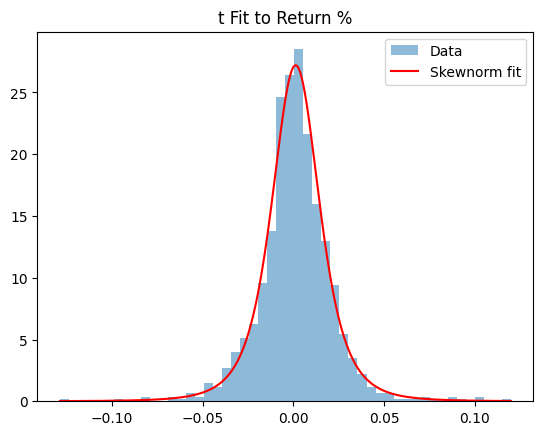

In [15]:
filtered = returns["AAPL"]
params_t = t.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = t.pdf(x, *params_t)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("t Fit to Return %")
plt.show()

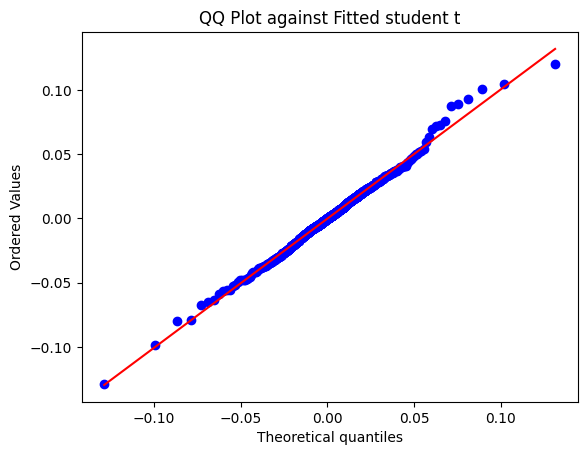

In [16]:
stats.probplot(filtered, dist=t(*params_t), plot=plt)
plt.title("QQ Plot against Fitted student t")
plt.show()


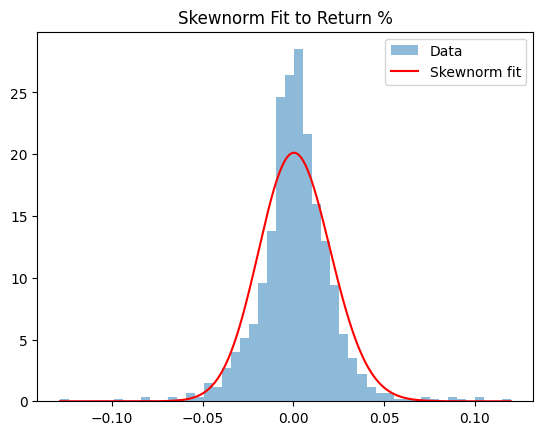

In [17]:
filtered = returns["AAPL"]
params_skew = skewnorm.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = skewnorm.pdf(x, *params_skew)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("Skewnorm Fit to Return %")
plt.show()

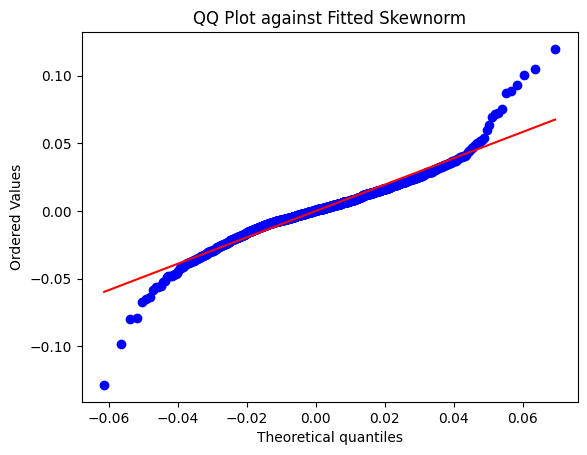

In [18]:
stats.probplot(filtered, dist=skewnorm(*params_skew), plot=plt)
plt.title("QQ Plot against Fitted Skewnorm")
plt.show()

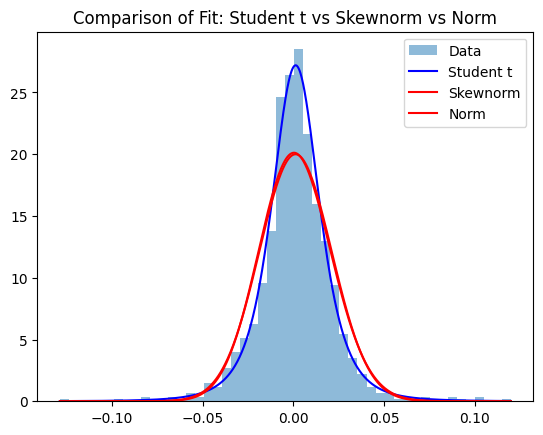

In [19]:
x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf_t = t.pdf(x, *params_t)
pdf_skew = skewnorm.pdf(x, *params_skew)
pdf_norm = norm.pdf(x, *params_norm)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf_t, 'b-', label="Student t")
plt.plot(x, pdf_skew, 'r-', label="Skewnorm")
plt.plot(x, pdf_norm, 'r-', label="Norm")
plt.legend()
plt.title("Comparison of Fit: Student t vs Skewnorm vs Norm")
plt.show()


<Axes: xlabel='AAPL', ylabel='Count'>

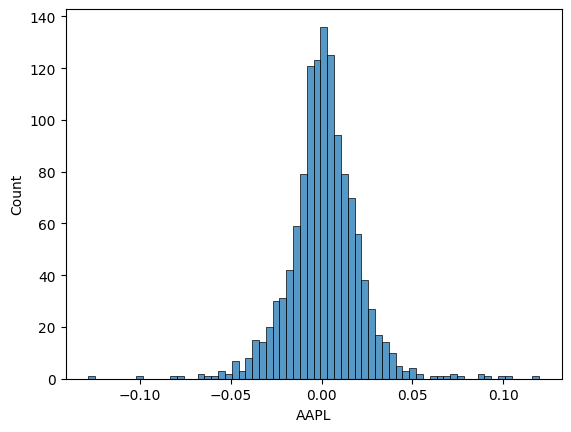

In [20]:
sns.histplot(returns["AAPL"])

In [127]:
df.head()

,open,high,low,close,volume,split_ratio,dividend,log_return,log_return_rol,log_return_rol_pct,return,return_pct,std_rol,log_return_std
date,,,,,,,,,,,,,,
2014-03-27,19.286428,19.339287,19.111429,19.195000,222031600,0.0,0.0,-0.004752,-0.020544,-2.033453,-0.091429,-0.620178,0.008836,0.008836
2014-03-28,19.225714,19.247856,19.080357,19.173571,200564000,0.0,0.0,-0.002716,-0.041368,-4.052441,-0.052143,-0.429686,0.008096,0.008096
2014-03-31,19.258215,19.314644,19.140356,19.169287,168669200,0.0,0.0,-0.004628,-0.048795,-4.762348,-0.088928,0.705465,0.008077,0.008077
2014-04-01,19.205713,19.352501,19.170357,19.344643,200760000,0.0,0.0,0.007208,-0.041569,-4.071668,0.138929,-2.562264,0.008233,0.008233
2014-04-02,19.370714,19.410000,19.295000,19.376785,180420800,0.0,0.0,0.000313,-0.027615,-2.723756,0.006071,-0.956301,0.007905,0.007905


<Axes: xlabel='log_return_std', ylabel='Count'>

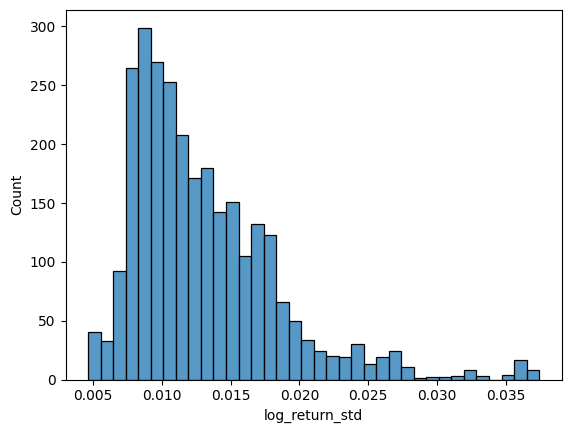

In [128]:
sns.histplot(df["log_return_std"])

In [36]:
VaR = norm.ppf(0.05, *params_norm)
VaR_skew = skewnorm.ppf(0.05, *params_skew)
Var_t = t.ppf(0.05, *params_t)

In [37]:
VaR, VaR_skew, Var_t

(np.float64(-0.03162896973036278),
 np.float64(-0.03098185402782047),
 np.float64(-0.02886041300861962))

In [38]:
print(len(returns["AAPL"][returns["AAPL"]<Var_t])/len(returns))

0.05807478122513922


In [23]:
def calculate_expected_var_norm(conf_level,mu, std ):

    ES = mu - std * norm.pdf(norm.ppf(1-conf_level)) / (1-conf_level)
    return ES

def calculate_expected_var_t(conf_level, df, loc, scale):

    t_alpha = t.ppf(1-conf_level, df)
    pdf = t.pdf(t_alpha, df)
    ES = loc - scale * ( (df + t_alpha**2) / (df - 1) ) * pdf / (1-conf_level)
    return ES

def calculated_expected_var_skew(conf_level, a, loc, scale):

    VaR_skew = skewnorm.ppf(1-conf_level, a, loc, scale)
    x = np.linspace(-10, VaR_skew, 1000)
    pdf_vals = skewnorm.pdf(x, a, loc, scale)
    ES = np.trapezoid(x * pdf_vals, x) / skewnorm.cdf(VaR_skew, a, loc, scale)
    return ES


In [42]:
print(calculate_expected_var_t(0.95, *params_t))
print(np.mean(returns["AAPL"][returns["AAPL"]<Var_t]))

-0.04523424223713371
-0.04237367702962422


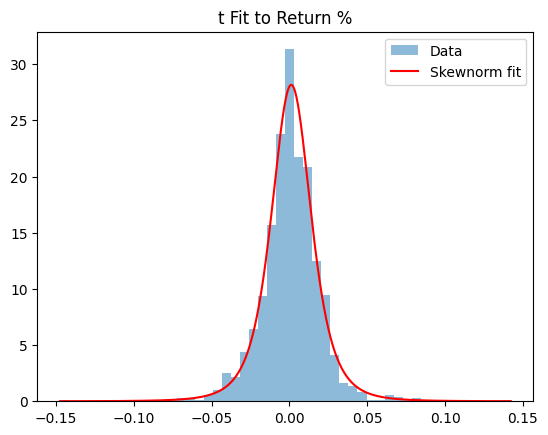

In [47]:
filtered = returns["MSFT"]
params_t = t.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = t.pdf(x, *params_t)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("t Fit to Return %")
plt.show()

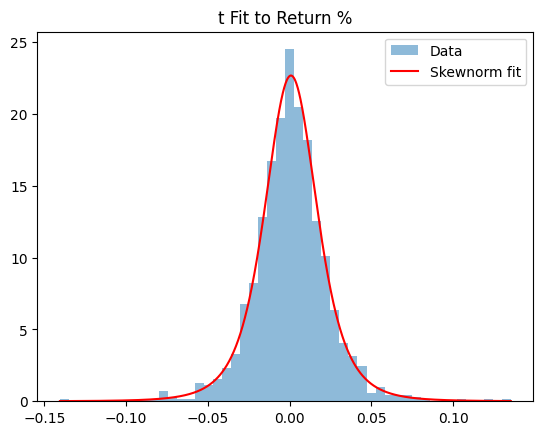

In [48]:
filtered = returns["AMZN"]
params_t = t.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = t.pdf(x, *params_t)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("t Fit to Return %")
plt.show()

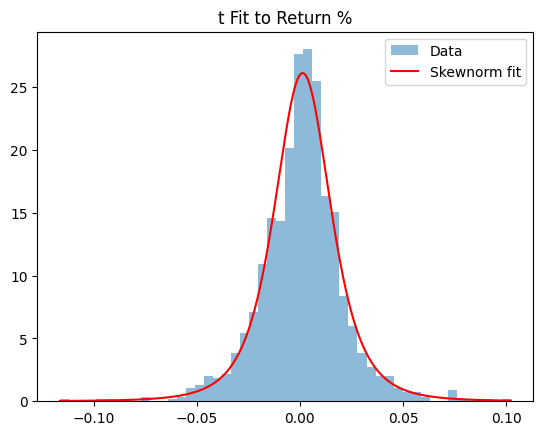

In [49]:
filtered = returns["GOOGL"]
params_t = t.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = t.pdf(x, *params_t)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("t Fit to Return %")
plt.show()

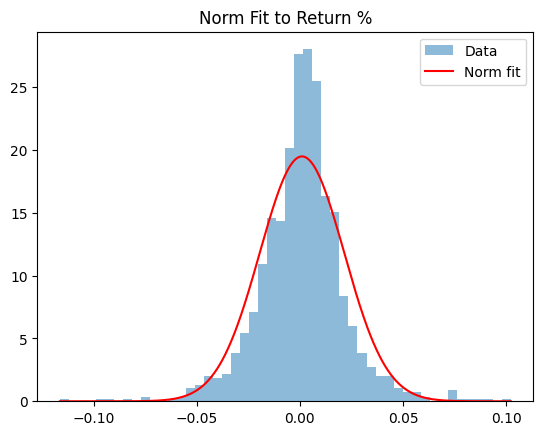

In [52]:
filtered = returns["GOOGL"]
params_norm = norm.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()